# 06 · Battery Dispatch from Probabilistic Forecasts

**PRT661 Assessment 3 · Group 4 · DKASC Alice Springs**

**The question this project was built for:** given a forecast of solar generation and its
uncertainty, when should the site battery charge, hold or discharge, and how much does the
forecast actually help?

Notebook 05 produced the forecasts. This notebook turns them into decisions and measures the
result against real site data.

**Part A · Make the forecast trustworthy.** Repair and calibrate the 80% interval, because the
battery rules will rely on it.

**Part B · Understand the site.** Load the real battery, solar, demand and grid measurements
recorded from 2024, and measure the battery's actual limits.

**Part C · Decide and evaluate.** Write the dispatch rules, simulate them hour by hour, compare
against perfect foresight and against what the real battery did, and test how sensitive the
result is.

**Why `p50` uses the absolute error model at both horizons.** Absolute error loss estimates the
median, the 50th percentile. With `q10` and `q90` from quantile loss, the three form one
consistent set of percentiles. At 1 hour this model's MAE is 3.66 kW against 3.61 kW for the
squared error model quoted in A2, a difference of 0.05 kW that does not affect any decision below.

In [1]:
# Setup
%matplotlib inline
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

REPO = Path("/Users/uttamshrestha/Desktop/Data Science Practice Unit/PRT661-solar-forecasting")
RAW, PROC, OUT = REPO/"Datasets"/"raw", REPO/"Datasets"/"processed", REPO/"Outputs"
FIG = OUT/"figures"; FIG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

fc = pd.read_parquet(PROC/"forecasts_hourly.parquet")

# daylight flag for the hour being forecast, taken from the feature store (notebook 04)
day = pd.read_parquet(PROC/"features_hourly.parquet", columns=["is_daylight"])
fc = fc.merge(day, left_on="target_time", right_index=True, how="left")

print(f"{len(fc):,} forecasts loaded, {fc.is_daylight.isna().sum()} without a daylight flag\n")
print(fc.groupby(["horizon", "fold"])
        .agg(first=("target_time", "min"), last=("target_time", "max"), n=("actual", "size"))
        .to_string())

113,677 forecasts loaded, 0 without a daylight flag

                           first                last      n
horizon fold                                               
1       1    2019-01-01 01:00:00 2020-12-31 01:00:00  17335
        2    2021-01-01 01:00:00 2022-12-31 01:00:00  16932
        3    2023-01-01 01:00:00 2023-12-31 01:00:00   8429
        4    2024-01-01 02:00:00 2025-08-23 04:00:00  14157
24      1    2019-01-02 00:00:00 2021-01-01 00:00:00  17335
        2    2021-01-02 00:00:00 2023-01-01 00:00:00  16932
        3    2023-01-02 00:00:00 2024-01-01 00:00:00   8419
        4    2024-01-02 00:00:00 2025-08-23 04:00:00  14138


## Part A · Make the forecast trustworthy

### 1 · Repair crossed interval edges

`q10` and `q90` come from two separately trained models that do not know about each other, so
occasionally the low edge lands above the high edge. Taking the smaller of the two as the low
edge and the larger as the high edge restores the order. `p50` is left untouched, so the
accuracy figures stand.

In [2]:
# Repair crossed interval edges
crossed = fc.q10 > fc.q90
print(f"crossed rows: {crossed.sum():,} ({100*crossed.mean():.1f}%)")
print(f"  in daylight: {int((crossed & (fc.is_daylight == 1)).sum()):,}")
print(f"  at night   : {int((crossed & (fc.is_daylight == 0)).sum()):,}")

fc["lo"] = fc[["q10", "q90"]].min(axis=1)
fc["hi"] = fc[["q10", "q90"]].max(axis=1)

fc["err"]      = (fc.p50 - fc.actual).abs()
fc["in_raw"]   = (fc.actual >= fc.q10) & (fc.actual <= fc.q90)
fc["in_fixed"] = (fc.actual >= fc.lo)  & (fc.actual <= fc.hi)
fc["width"]    = fc.hi - fc.lo
dl = fc.is_daylight == 1
g, gd = fc.groupby(["horizon", "fold"]), fc[dl].groupby(["horizon", "fold"])

summary = pd.DataFrame({
    "MAE_kW":            g.err.mean(),
    "cover_before":      g.in_raw.mean(),
    "cover_after":       g.in_fixed.mean(),
    "cover_daylight":    gd.in_fixed.mean(),
    "width_daylight_kW": gd.width.mean(),
}).round(3)

print("\nTarget coverage is 0.800 in every fold:\n")
print(summary.to_string())

crossed rows: 3,929 (3.5%)
  in daylight: 111
  at night   : 3,818

Target coverage is 0.800 in every fold:

              MAE_kW  cover_before  cover_after  cover_daylight  width_daylight_kW
horizon fold                                                                      
1       1      3.070         0.778        0.781           0.744             19.853
        2      3.902         0.653        0.657           0.755             22.672
        3      3.790         0.788        0.790           0.802             23.743
        4      3.869         0.702        0.710           0.780             24.464
24      1      5.781         0.670        0.685           0.780             38.203
        2      7.534         0.823        0.826           0.825             50.306
        3      7.334         0.723        0.731           0.846             60.121
        4      7.203         0.691        0.704           0.707             45.949


### 2 · Rolling conformal calibration

Daylight coverage drifts from year to year (0.78, 0.83, 0.85, then 0.71 at 24 hours), so a
single fixed correction cannot work: calibrating 2024 on 2023, when the interval was too wide,
would narrow it further and make coverage worse.

Instead, the interval is corrected **every day using only the previous 30 days**. For each past
daylight hour, the score is how far the actual value fell outside the interval (negative if it
fell inside). The correction `Q` is the score that 80% of past hours stayed below. Adding `Q` to
both edges would have caught 80% of those 30 days. A negative `Q` narrows an interval that has
been too cautious.

Only scores for target days at least two days old are used, so every correction could have been
computed at the moment the forecast was issued. Night hours are left unchanged: solar output is
zero and the battery decision does not depend on them.

Method: conformalised quantile regression (Romano, Patterson and Candès, 2019), applied on a
rolling window to track drift (Gibbs and Candès, 2021).

In [3]:
# Rolling conformal calibration of the daylight interval
HORIZONS = (1, 24)
ALPHA, WINDOW = 0.20, 30        # target 80% coverage, look back 30 days

# score > 0: actual fell outside the interval by that many kW; score < 0: inside
fc["score"] = np.maximum(fc.lo - fc.actual, fc.actual - fc.hi)
fc["date"]  = fc.target_time.dt.normalize()
fc["Q"]     = 0.0

for h in HORIZONS:
    m = (fc.horizon == h) & dl
    d = fc.loc[m, ["date", "score"]].sort_values("date")
    dates, scores = d.date.to_numpy(), d.score.to_numpy()

    days = np.unique(dates)
    q_by_day = {}
    for D in days:
        # targets from D-31 up to D-2: all known before any forecast for day D is issued
        i0, i1 = np.searchsorted(dates, [D - np.timedelta64(WINDOW + 1, "D"),
                                         D - np.timedelta64(1, "D")])
        s = scores[i0:i1]
        if len(s) < 50:          # not enough history yet, leave unchanged
            continue
        level = min(1.0, np.ceil((len(s) + 1) * (1 - ALPHA)) / len(s))
        q_by_day[D] = np.quantile(s, level, method="higher")

    q_by_day = pd.Series(q_by_day)
    q_by_day.index = pd.to_datetime(q_by_day.index)
    fc.loc[m, "Q"] = fc.loc[m, "date"].map(q_by_day).fillna(0.0)

# calibrated interval; if a strongly negative Q would cross the edges, collapse to p50
fc["lo_c"], fc["hi_c"] = fc.lo - fc.Q, fc.hi + fc.Q
bad = fc.lo_c > fc.hi_c
fc.loc[bad, "lo_c"] = fc.loc[bad, "p50"]
fc.loc[bad, "hi_c"] = fc.loc[bad, "p50"]

fc["in_cal"]  = (fc.actual >= fc.lo_c) & (fc.actual <= fc.hi_c)
fc["width_c"] = fc.hi_c - fc.lo_c

gd = fc[dl].groupby(["horizon", "fold"])
cal = pd.DataFrame({
    "cover_raw":    gd.in_fixed.mean(),
    "cover_cal":    gd.in_cal.mean(),
    "width_raw_kW": gd.width.mean(),
    "width_cal_kW": gd.width_c.mean(),
    "mean_Q_kW":    gd.Q.mean(),
}).round(3)

print("Daylight hours only. Target coverage 0.800.\n")
print(cal.to_string())
print(f"\naverage distance from 0.80:  raw {abs(cal.cover_raw - .8).mean():.3f}"
      f"   calibrated {abs(cal.cover_cal - .8).mean():.3f}")
print(f"rows collapsed to p50: {int(bad.sum())}")

Daylight hours only. Target coverage 0.800.

              cover_raw  cover_cal  width_raw_kW  width_cal_kW  mean_Q_kW
horizon fold                                                             
1       1         0.744      0.797        19.853        20.614      0.375
        2         0.755      0.803        22.672        23.777      0.552
        3         0.802      0.805        23.743        23.834      0.045
        4         0.780      0.799        24.464        24.977      0.256
24      1         0.780      0.796        38.203        38.792      0.288
        2         0.825      0.805        50.306        49.885     -0.219
        3         0.846      0.810        60.121        58.598     -0.769
        4         0.707      0.793        45.949        48.359      1.200

average distance from 0.80:  raw 0.038   calibrated 0.005
rows collapsed to p50: 305


### Figure 11 · Daylight coverage by month, before and after calibration

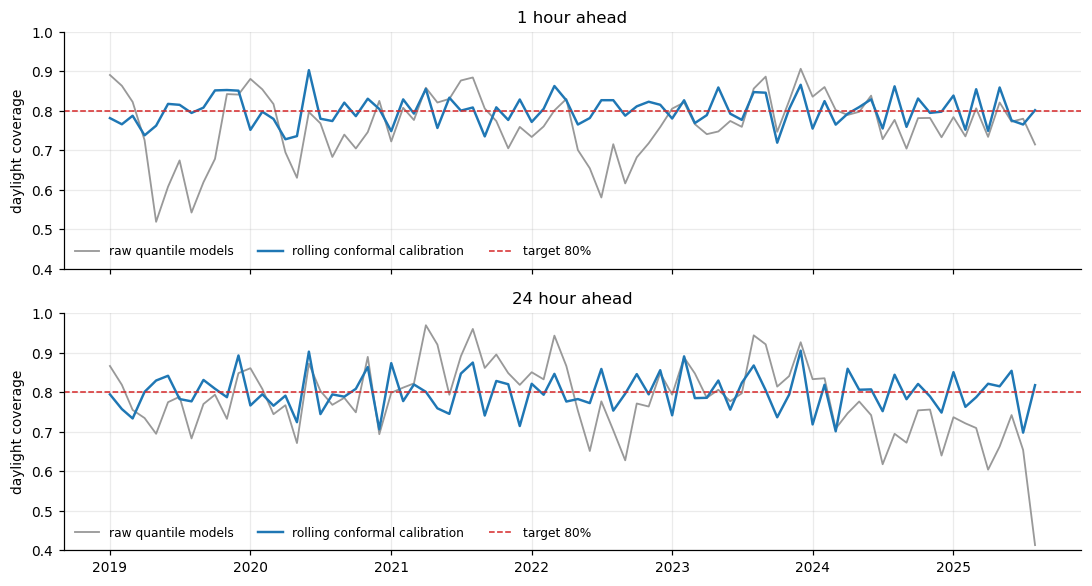

h= 1  monthly coverage spread (std):  raw 0.080   calibrated 0.038
h=24  monthly coverage spread (std):  raw 0.093   calibrated 0.048


In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
for a, h in zip(ax, HORIZONS):
    d = fc[(fc.horizon == h) & dl]
    mon = d.groupby(d.target_time.dt.to_period("M"))[["in_fixed", "in_cal"]].mean()
    mon.index = mon.index.to_timestamp()
    a.plot(mon.index, mon.in_fixed, color="#999999", lw=1.2, label="raw quantile models")
    a.plot(mon.index, mon.in_cal,   color="#1f77b4", lw=1.6, label="rolling conformal calibration")
    a.axhline(0.8, color="#d62728", ls="--", lw=1, label="target 80%")
    a.set_ylim(0.4, 1.0); a.set_ylabel("daylight coverage")
    a.set_title(f"{h} hour ahead")
    a.legend(frameon=False, fontsize=8, ncol=3, loc="lower left")
fig.tight_layout(); fig.savefig(FIG/"fig11_interval_calibration.png"); plt.show()

for h in HORIZONS:
    d = fc[(fc.horizon == h) & dl]
    mon = d.groupby(d.target_time.dt.to_period("M"))[["in_fixed", "in_cal"]].mean()
    print(f"h={h:>2}  monthly coverage spread (std):  raw {mon.in_fixed.std():.3f}"
          f"   calibrated {mon.in_cal.std():.3f}")

## Part B · Understand the site

### 3 · Load the site telemetry recorded from 2024

From 2024 the yearly extracts carry thirteen site level columns that did not exist before: battery,
solar, demand and grid, each as active, reactive and apparent power. Five are needed here.

Nothing is assumed about units, sign conventions or error codes. The values are loaded and
described first, and every decision about them is taken from what the data shows. This is the
lesson of Assessment 2, where a sentinel rule applied without inspection destroyed the cumulative
energy register.

In [5]:
# Loading the site telemetry recorded from 2024
SITE = {
    "239_DKA_Totals_BESS_Active_Power":        "bess_kw",
    "239_DKA_Totals_BESS_State_of_Charge":     "soc",
    "240_DKA_Totals_Site_Demand_Active_Power": "demand_kw",
    "241_DKA_Totals_PV_Active_Power":          "pv_kw",
    "242_DKA_Totals_Grid_Active_Power":        "grid_kw",
}

parts = [pd.read_csv(RAW/f"Alice_Springs_{yr}.csv", usecols=["timestamp", *SITE],
                     parse_dates=["timestamp"], low_memory=False)
         for yr in (2024, 2025)]
raw5 = pd.concat(parts, ignore_index=True).rename(columns=SITE)

n_read = len(raw5)
raw5 = raw5.drop_duplicates("timestamp").set_index("timestamp").sort_index()
raw5 = raw5.apply(pd.to_numeric, errors="coerce")

print(f"5 minute rows read: {n_read:,}   year-boundary duplicates dropped: {n_read - len(raw5):,}")
print(f"range: {raw5.index.min()}  to  {raw5.index.max()}\n")

print("What the raw 5 minute values look like:")
print(raw5.describe(percentiles=[.01, .05, .5, .95, .99]).T.round(2).to_string())

print("\nMissing %:")
print((100 * raw5.isna().mean()).round(2).to_string())

print("\nShare of readings that are negative, zero, positive:")
print(pd.DataFrame({
    "neg_%":  (100 * (raw5 < 0).mean()).round(1),
    "zero_%": (100 * (raw5 == 0).mean()).round(1),
    "pos_%":  (100 * (raw5 > 0).mean()).round(1),
}).to_string())

5 minute rows read: 210,779   year-boundary duplicates dropped: 0
range: 2024-01-01 00:00:00  to  2026-01-01 23:55:00

What the raw 5 minute values look like:
              count   mean    std     min      1%     5%    50%     95%     99%     max
bess_kw    209848.0  -1.93  24.97 -183.45  -90.06 -58.94  -0.77   36.59   55.09  196.79
soc        201657.0  28.02  28.98    0.00    0.00   0.00  14.23   86.65   94.82   94.85
grid_kw    202698.0  33.05  55.37 -185.27 -150.12 -74.46  42.51  120.49  176.39  349.10
pv_kw      209854.0  55.71  79.74   -7.53   -6.29  -0.92  -0.47  194.65  312.87  471.18
demand_kw  209706.0  83.46  64.13  -93.56    8.35  28.99  53.88  232.26  301.02  483.16

Missing %:
bess_kw      0.44
soc          4.33
grid_kw      3.83
pv_kw        0.44
demand_kw    0.51

Share of readings that are negative, zero, positive:
           neg_%  zero_%  pos_%
bess_kw     53.6    13.9   32.1
soc          0.0     6.3   89.3
grid_kw     22.8     0.9   72.5
pv_kw       51.2     0.3   48

### 4 · Hourly energy and the sign conventions

Mean power across an hour in kW equals the energy in kWh for that hour, so hourly means are used
from here on. Hours with fewer than 10 of their 12 readings are dropped.

The direction of battery and grid power is not documented. It is determined from physics: in every
hour, what the site consumes must equal what arrives from solar, the grid and the battery. Of the
four possible sign combinations, only the correct one balances.

In [6]:
# 4 Hourly energy and the sign conventions
hourly = raw5.drop(columns="soc").resample("1h").mean()
hourly["soc"]   = raw5.soc.resample("1h").last()        # state of charge at the end of the hour
hourly["n_obs"] = raw5.pv_kw.resample("1h").count()
site = hourly[hourly.n_obs >= 10].drop(columns="n_obs")
print(f"hourly rows: {len(hourly):,}   kept (at least 10 of 12 readings): {len(site):,}\n")

# which sign combination makes the site balance?
b = site.dropna(subset=["pv_kw", "grid_kw", "bess_kw", "demand_kw"])
candidates = {
    "demand = pv + grid + bess": b.pv_kw + b.grid_kw + b.bess_kw,
    "demand = pv + grid - bess": b.pv_kw + b.grid_kw - b.bess_kw,
    "demand = pv - grid + bess": b.pv_kw - b.grid_kw + b.bess_kw,
    "demand = pv - grid - bess": b.pv_kw - b.grid_kw - b.bess_kw,
}
balance = pd.DataFrame({
    name: {"mean_abs_gap_kW": (b.demand_kw - s).abs().mean(),
           "hours_within_2kW_%": 100 * ((b.demand_kw - s).abs() < 2).mean()}
    for name, s in candidates.items()
}).T.round(2)
print("Energy balance test, one row per possible sign convention:")
print(balance.to_string())

# what does each flow look like across an average day?
print("\nAverage by hour of day (kW, and % for soc):")
by_hour = site.groupby(site.index.hour)[["pv_kw", "demand_kw", "grid_kw", "bess_kw", "soc"]].mean()
by_hour.index.name = "hour"
print(by_hour.round(1).to_string())

hourly rows: 17,568   kept (at least 10 of 12 readings): 17,500

Energy balance test, one row per possible sign convention:
                           mean_abs_gap_kW  hours_within_2kW_%
demand = pv + grid + bess             2.82               96.25
demand = pv + grid - bess            26.66               21.90
demand = pv - grid + bess            99.66                1.94
demand = pv - grid - bess           118.90                0.60

Average by hour of day (kW, and % for soc):
      pv_kw  demand_kw  grid_kw  bess_kw   soc
hour                                          
0       0.2       47.4     45.3      2.0  19.9
1       0.2       46.7     45.4      1.1  18.9
2       0.2       46.5     45.6      0.7  18.1
3       0.2       46.4     46.0      0.1  17.4
4       0.2       46.7     45.4      1.0  16.8
5       0.3       48.3     47.1      1.3  16.1
6       2.5       64.0     60.3      1.7  15.1
7      22.6       91.0     70.0      0.8  14.5
8      73.8      117.8     53.8     -4.5  15.3

### 5 · How Master Meter 1 relates to the site, and where the opportunity is

The energy balance fixes the sign conventions: **battery positive is discharging, grid positive
is importing**. In the average day the battery charges from 8 am to 3 pm, reaches only about half
charge, and discharges through the evening and night while the site continues to import around
45 kW from the grid.

The forecasts in Part A are for Master Meter 1, but the battery serves the whole site. If total
site solar is a stable multiple of Master Meter 1, the forecast can be scaled to the site.

In [7]:
# 5. Master Meter 1 against the whole site
mm1 = (pd.read_parquet(PROC/"features_hourly.parquet", columns=["y", "is_daylight"])
         .rename(columns={"y": "mm1_kw"}))
j = site.join(mm1, how="inner")
sunny = j[(j.is_daylight == 1) & (j.mm1_kw > 10) & (j.pv_kw > 10)]
ratio = sunny.pv_kw / sunny.mm1_kw
k = ratio.median()

print(f"overlap with Master Meter 1: {j.index.min()}  to  {j.index.max()}  ({len(j):,} hours)")
print(f"daylight correlation, site solar vs Master Meter 1: {sunny.pv_kw.corr(sunny.mm1_kw):.3f}")
print(f"site solar / Master Meter 1: median {k:.2f},  middle 50% {ratio.quantile(.25):.2f} to {ratio.quantile(.75):.2f}")
print(f"error from scaling alone (site solar vs {k:.2f} x MM1), daylight MAE: "
      f"{(sunny.pv_kw - k*sunny.mm1_kw).abs().mean():.1f} kW\n")

print("median ratio by month:")
print(ratio.groupby(ratio.index.to_period("M")).median().round(2).to_string())

# ── Where the energy went over the overlap period (hourly kW summed = kWh) ──
e = j
imp, exp = e.grid_kw.clip(lower=0).sum()/1e3, (-e.grid_kw).clip(lower=0).sum()/1e3
chg, dis = (-e.bess_kw).clip(lower=0).sum()/1e3, e.bess_kw.clip(lower=0).sum()/1e3
days = (e.index.max() - e.index.min()).days

print(f"\nOver {days} days:")
print(f"  bought from the grid   {imp:8.1f} MWh")
print(f"  solar sold to the grid {exp:8.1f} MWh")
print(f"  battery charged        {chg:8.1f} MWh")
print(f"  battery discharged     {dis:8.1f} MWh   (round trip efficiency {dis/chg:.1%})")

overlap with Master Meter 1: 2024-01-01 00:00:00  to  2025-08-23 05:00:00  (14,340 hours)
daylight correlation, site solar vs Master Meter 1: 0.858
site solar / Master Meter 1: median 1.11,  middle 50% 1.10 to 1.14
error from scaling alone (site solar vs 1.11 x MM1), daylight MAE: 12.6 kW

median ratio by month:
timestamp
2024-01    2.21
2024-02    2.21
2024-03    1.13
2024-04    1.14
2024-05    1.14
2024-06    1.13
2024-07    1.13
2024-08    1.13
2024-09    1.10
2024-10    1.10
2024-11    1.10
2024-12    1.09
2025-01    1.10
2025-02    1.10
2025-03    1.10
2025-04    1.11
2025-05    1.11
2025-06    1.11
2025-07    1.11
2025-08    1.11
Freq: M

Over 600 days:
  bought from the grid      590.9 MWh
  solar sold to the grid    107.3 MWh
  battery charged            99.9 MWh
  battery discharged         73.0 MWh   (round trip efficiency 73.1%)


### Figure 12 · The average day at the site

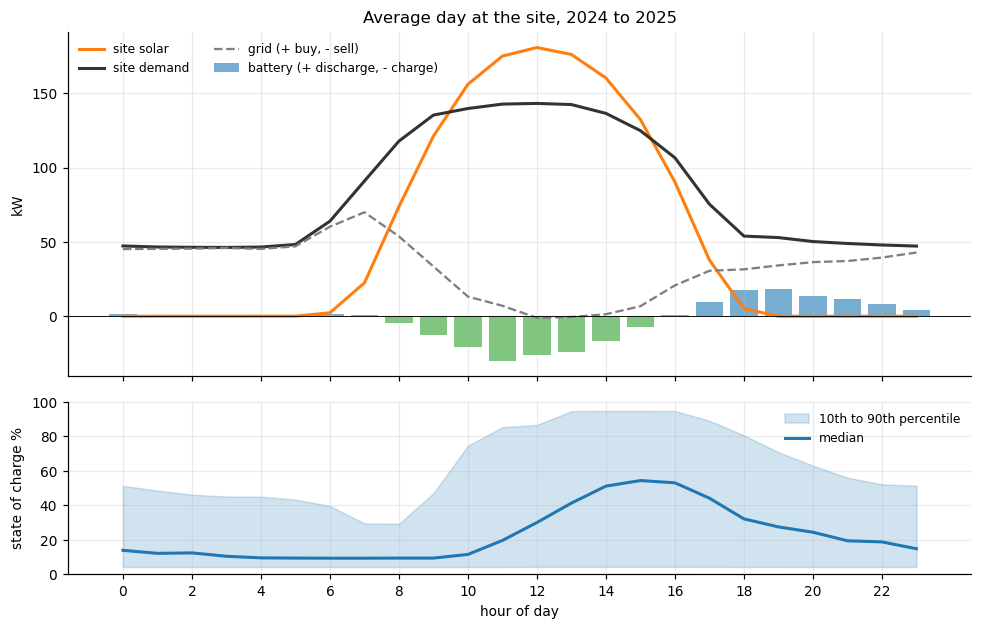

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(9, 5.8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
hr = by_hour.index
ax[0].plot(hr, by_hour.pv_kw,     color="#ff7f0e", lw=2,   label="site solar")
ax[0].plot(hr, by_hour.demand_kw, color="#333333", lw=2,   label="site demand")
ax[0].plot(hr, by_hour.grid_kw,   color="#7f7f7f", lw=1.5, ls="--", label="grid (+ buy, - sell)")
ax[0].bar(hr, by_hour.bess_kw, color=np.where(by_hour.bess_kw < 0, "#2ca02c", "#1f77b4"),
          alpha=.6, label="battery (+ discharge, - charge)")
ax[0].axhline(0, color="black", lw=.6)
ax[0].set_ylabel("kW"); ax[0].set_title("Average day at the site, 2024 to 2025")
ax[0].legend(frameon=False, fontsize=8, ncol=2)

q = site.groupby(site.index.hour).soc.quantile([.1, .5, .9]).unstack()
ax[1].fill_between(q.index, q[.1], q[.9], color="#1f77b4", alpha=.2, label="10th to 90th percentile")
ax[1].plot(q.index, q[.5], color="#1f77b4", lw=2, label="median")
ax[1].set_ylim(0, 100); ax[1].set_ylabel("state of charge %"); ax[1].set_xlabel("hour of day")
ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"fig12_site_average_day.png"); plt.show()

### 6 · What the real battery can do

Two decisions follow from step 5. The site changed configuration at the end of February 2024, so
only data from 1 March 2024 are used. The factor that scales the Master Meter 1 forecast to the
whole site is estimated from March 2024 alone and then held fixed, so every later month is an
honest test of it.

The battery's specification is not published with the data, so every parameter the simulation
needs is measured: power limits, state of charge range, capacity, efficiency and standby draw.
Capacity comes from matching energy in and out against the change in state of charge. Comparing
the two directions gives the efficiency of real charge and discharge cycles, separated from the
standby draw that lowered the whole-period figure to 73%.

In [9]:
# 6  What the real battery can do
BREAK, K_END = "2024-03-01", "2024-03-31"      # configuration change, and the month used for scaling

# scale factor from Master Meter 1 to whole-site solar, fitted on March 2024 only
jj  = j.loc[BREAK:]
sun = jj[(jj.is_daylight == 1) & (jj.mm1_kw > 10) & (jj.pv_kw > 10)]
K   = (sun.loc[:K_END].pv_kw / sun.loc[:K_END].mm1_kw).median()
later = sun.loc["2024-04-01":]
print(f"scale factor K = {K:.3f}  (fitted on March 2024 only)")
print(f"tested on April 2024 onward: correlation {later.pv_kw.corr(later.mm1_kw):.3f}, "
      f"scaling MAE {(later.pv_kw - K*later.mm1_kw).abs().mean():.1f} kW\n")

# battery behaviour from 1 March 2024
IDLE = 2.0                                      # kW; hourly battery power within +/-2 kW counts as idle
b6 = site.loc[BREAK:].dropna(subset=["bess_kw", "soc"])
state = np.select([b6.bess_kw < -IDLE, b6.bess_kw > IDLE], ["charging", "discharging"], "idle")
print("hours by battery state:")
print(pd.Series(state).value_counts().to_string())

standby = b6.bess_kw[state == "idle"].mean()
chg_kw  = -b6.bess_kw[state == "charging"]
dis_kw  =  b6.bess_kw[state == "discharging"]
print(f"\nmean power while idle (standby): {standby:+.2f} kW")
print(f"charging power    (hourly kW): median {chg_kw.median():5.1f}   99th pct {chg_kw.quantile(.99):5.1f}   max {chg_kw.max():5.1f}")
print(f"discharging power (hourly kW): median {dis_kw.median():5.1f}   99th pct {dis_kw.quantile(.99):5.1f}   max {dis_kw.max():5.1f}")

zero = b6.soc == 0
nz   = b6.soc[~zero]
print(f"\nsoc exactly 0 in {100*zero.mean():.1f}% of hours (mean |battery power| then {b6.bess_kw[zero].abs().mean():.1f} kW)")
print(f"soc operating range, excluding zeros: {nz.quantile(.01):.1f}% to {nz.quantile(.99):.1f}%")

# capacity and efficiency from energy against change in state of charge
consec = b6.index.to_series().diff() == pd.Timedelta("1h")
dsoc   = b6.soc.diff().where(consec)
ok     = dsoc.notna() & (b6.soc > 0) & (b6.soc.shift() > 0)
c_hr   = ok & (state == "charging")    & (dsoc >  0.5)
d_hr   = ok & (state == "discharging") & (dsoc < -0.5)
kwh_in_per_pct  = (-b6.bess_kw[c_hr]).sum() / dsoc[c_hr].sum()
kwh_out_per_pct = ( b6.bess_kw[d_hr]).sum() / (-dsoc[d_hr]).sum()
RT = kwh_out_per_pct / kwh_in_per_pct

print(f"\nenergy to add 1% of charge    : {kwh_in_per_pct:.2f} kWh   ({c_hr.sum():,} charging hours)")
print(f"energy from removing 1% charge: {kwh_out_per_pct:.2f} kWh   ({d_hr.sum():,} discharging hours)")
print(f"round trip on real cycles     : {RT:.1%}   (whole period including standby was 73.1%)")

BATT = {
    "capacity_kwh":   100 * np.sqrt(kwh_in_per_pct * kwh_out_per_pct),
    "soc_min":        nz.quantile(.01) / 100,
    "soc_max":        nz.quantile(.99) / 100,
    "p_charge_kw":    chg_kw.quantile(.99),
    "p_discharge_kw": dis_kw.quantile(.99),
    "eta_oneway":     np.sqrt(RT),
    "standby_kw":     max(0.0, -standby),
}
print("\nBattery model used from here on:")
for key, v in BATT.items():
    print(f"  {key:<15} {v:8.3f}")

scale factor K = 1.135  (fitted on March 2024 only)
tested on April 2024 onward: correlation 0.995, scaling MAE 3.4 kW

hours by battery state:
idle           6935
charging       4729
discharging    4370

mean power while idle (standby): -0.72 kW
charging power    (hourly kW): median   5.1   99th pct 114.8   max 146.0
discharging power (hourly kW): median   7.2   99th pct  63.6   max 153.1

soc exactly 0 in 7.0% of hours (mean |battery power| then 0.0 kW)
soc operating range, excluding zeros: 2.2% to 94.8%

energy to add 1% of charge    : 3.89 kWh   (2,411 charging hours)
energy from removing 1% charge: 3.22 kWh   (4,340 discharging hours)
round trip on real cycles     : 82.8%   (whole period including standby was 73.1%)

Battery model used from here on:
  capacity_kwh     354.271
  soc_min            0.022
  soc_max            0.948
  p_charge_kw      114.773
  p_discharge_kw    63.574
  eta_oneway         0.910
  standby_kw         0.715


## Part C · Decide and evaluate

### 7 · The simulation table

The simulation runs hour by hour from 1 April 2024 to 22 August 2025: after the month used to fit
the scale factor, and within the period the forecasts cover.

**Prices.** The site's electricity contract is not available, so an illustrative time of use
tariff is used, of the structure common in Australian commercial tariffs: peak 4 pm to 10 pm at
0.40 per kWh, off-peak 10 pm to 7 am at 0.15, shoulder otherwise at 0.25, and $0.07 paid for
exported solar. Energy results are reported alongside cost so the conclusions do not rest on
these prices.

**What is known the evening before.** Tomorrow's solar comes from the 24 hour ahead forecast,
which for every hour from 7 am to 4 pm tomorrow was issued before 10 pm tonight. Tomorrow's demand
is forecast as the average of the same hour over the previous seven days.

In [10]:
# 7 The hourly table the simulation runs on
SIM_START, SIM_END = "2024-04-01", "2025-08-22 23:00"

# the battery reached 153 kW discharging; its 99th percentile (64 kW) reflects night demand,
# not the battery, so the charging limit is used in both directions
BATT["p_discharge_kw"] = BATT["p_charge_kw"]

# actual site solar and demand on a complete hourly grid, from 1 March for the demand history
full = pd.date_range("2024-03-01", SIM_END, freq="1h")
act  = site[["pv_kw", "demand_kw", "grid_kw", "bess_kw"]].reindex(full)
gaps = act[["pv_kw", "demand_kw"]].isna().any(axis=1).loc[SIM_START:].sum()
for c in ["pv_kw", "demand_kw"]:
    act[c] = act[c].interpolate(limit=3)                                  # short gaps
    act[c] = act[c].fillna(act.groupby(act.index.hour)[c].ffill())       # longer: same hour, last known day

# demand forecast: mean of the same hour over the previous 7 days (known the evening before)
dem_fc = sum(act.demand_kw.shift(24 * i) for i in range(1, 8)) / 7

# site solar forecast: Master Meter 1, 24 hours ahead, scaled by K (fixed in step 6)
f24     = fc[fc.horizon == 24].set_index("target_time")
f24     = f24[~f24.index.duplicated()]
pv_fc50 = (K * f24.p50).reindex(full)
pv_fclo = (K * f24.lo_c).reindex(full)
missing = pv_fc50.loc[SIM_START:].isna().sum()
yday    = act.pv_kw.shift(24)                                             # fallback: same hour yesterday
pv_fc50, pv_fclo = pv_fc50.fillna(yday), pv_fclo.fillna(yday)

sim = pd.DataFrame({"pv": act.pv_kw, "demand": act.demand_kw,
                    "grid_recorded": act.grid_kw, "bess_recorded": act.bess_kw,
                    "pv_fc50": pv_fc50, "pv_fclo": pv_fclo, "dem_fc": dem_fc}).loc[SIM_START:SIM_END]

# illustrative time of use tariff ($/kWh)
TARIFF, FEED_IN = {"offpeak": 0.15, "shoulder": 0.25, "peak": 0.40}, 0.07
hr = sim.index.hour
sim["period"] = np.select([(hr >= 16) & (hr <= 21), (hr >= 22) | (hr <= 6)], ["peak", "offpeak"], "shoulder")
sim["price"]  = sim.period.map(TARIFF)

day = (hr >= 7) & (hr <= 15)
print(f"simulation period: {sim.index.min()}  to  {sim.index.max()}   ({len(sim):,} hours, {len(sim)//24} days)")
print(f"hours with filled solar or demand: {gaps}   hours using the fallback solar forecast: {missing}")
print(f"\nforecast quality for tomorrow's planning hours (07:00 to 15:59):")
print(f"  site solar, median forecast MAE {(sim.pv_fc50 - sim.pv)[day].abs().mean():5.1f} kW   "
      f"(actual mean {sim.pv[day].mean():5.1f} kW)")
print(f"  site solar, low edge below actual in {100*(sim.pv_fclo <= sim.pv)[day].mean():.0f}% of hours")
print(f"  site demand, 7 day forecast MAE     {(sim.dem_fc - sim.demand)[day].abs().mean():5.1f} kW   "
      f"(actual mean {sim.demand[day].mean():5.1f} kW)")
print("\nbattery model:", {k: round(v, 3) for k, v in BATT.items()})

simulation period: 2024-04-01 00:00:00  to  2025-08-22 23:00:00   (12,216 hours, 509 days)
hours with filled solar or demand: 62   hours using the fallback solar forecast: 80

forecast quality for tomorrow's planning hours (07:00 to 15:59):
  site solar, median forecast MAE  17.9 kW   (actual mean 123.6 kW)
  site solar, low edge below actual in 90% of hours
  site demand, 7 day forecast MAE      50.6 kW   (actual mean 128.1 kW)

battery model: {'capacity_kwh': np.float64(354.271), 'soc_min': np.float64(0.022), 'soc_max': np.float64(0.948), 'p_charge_kw': np.float64(114.773), 'p_discharge_kw': np.float64(114.773), 'eta_oneway': np.float64(0.91), 'standby_kw': np.float64(0.715)}


### 8 · Hour by hour battery simulation

Every strategy uses the battery measured in step 6 and the same two rules through the day: surplus
solar is always stored if there is room, because stored solar is worth more than the export
price; and the battery discharges only in peak hours, when grid power is most expensive.

They differ in one decision, taken at 10 pm each night: **how much cheap off-peak grid energy to
store for tomorrow's peak.** Too little, and tomorrow's peak is bought at the peak price. Too
much, and the battery is already full when tomorrow's free solar arrives, so that solar is
exported cheaply.

| Strategy | Tonight's decision |
|---|---|
| No battery | none |
| Solar only, no forecast | never buy from the grid |
| Always fill overnight | fill to the top every night |
| Forecast, median | buy only what tomorrow's median solar forecast will not supply |
| Forecast, cautious | the same, using the calibrated low edge of the forecast |
| Perfect foresight | the same, using what actually happened: the best this rule can do |
| Recorded battery | the battery as actually operated, priced on the same tariff |

The recorded battery was not operated for this tariff, so its row shows how the real operation
would have fared under these prices, not how well its operator did.

In [11]:
# 8 · Hour by hour battery simulation
def simulate(sim, mode, plan_pv=None, plan_dem=None, batt=BATT, scale=1.0):
    """mode: 'no battery', 'solar only', 'always fill', or 'planned' (uses plan_pv, plan_dem)."""
    cap = batt["capacity_kwh"] * scale
    e_min, e_max = batt["soc_min"] * cap, batt["soc_max"] * cap
    p_c, p_d = batt["p_charge_kw"] * scale, batt["p_discharge_kw"] * scale
    eta, standby = batt["eta_oneway"], batt["standby_kw"]

    pv, dem, hrs = sim.pv.to_numpy(), sim.demand.to_numpy(), sim.index.hour.to_numpy()
    res = np.zeros((len(sim), 5))
    e, target = (e_min + e_max) / 2, 0.0          # start half full; nothing to buy yet

    for t in range(len(sim)):
        h, net = hrs[t], pv[t] - dem[t]
        if mode == "no battery":
            res[t] = (max(0.0, -net), max(0.0, net), 0.0, 0.0, 0.0)
            continue

        # 22:00, tonight's decision: how much cheap grid energy to store for tomorrow's peak
        if h == 22 and mode in ("always fill", "planned"):
            solar = 0.0
            if mode == "planned":
                tomorrow = slice(t + 9, t + 18)                      # 07:00 to 15:59
                solar = np.clip(plan_pv[tomorrow] - plan_dem[tomorrow], 0, p_c).sum() * eta
            target = max(0.0, (e_max - e) - solar) / eta             # grid kWh to buy tonight
        if h == 7:
            target = 0.0

        imp, exp, chg, dis = standby, 0.0, 0.0, 0.0
        if net >= 0:                                                 # surplus solar: store it
            chg = min(net, p_c, (e_max - e) / eta)
            e  += chg * eta
            exp = net - chg
        else:
            deficit = -net
            if 16 <= h <= 21:                                        # peak price: use the battery
                dis = min(deficit, p_d, (e - e_min) * eta)
                e  -= dis / eta
            imp += deficit - dis

        if target > 0 and (h >= 22 or h <= 6):                      # off-peak grid charging
            g = min(target, p_c - chg, (e_max - e) / eta)
            if g > 0:
                e += g * eta; chg += g; imp += g; target -= g

        res[t] = (imp, exp, chg, dis, e)
    return pd.DataFrame(res, index=sim.index, columns=["imp", "exp", "chg", "dis", "stored"])


pv_true, dem_true = sim.pv.to_numpy(), sim.demand.to_numpy()
runs = {
    "no battery":                    simulate(sim, "no battery"),
    "solar only, no forecast":       simulate(sim, "solar only"),
    "always fill overnight":         simulate(sim, "always fill"),
    "forecast, median":              simulate(sim, "planned", sim.pv_fc50.to_numpy(), sim.dem_fc.to_numpy()),
    "forecast, cautious (low edge)": simulate(sim, "planned", sim.pv_fclo.to_numpy(), sim.dem_fc.to_numpy()),
    "perfect foresight":             simulate(sim, "planned", pv_true, dem_true),
}
runs["recorded battery, as operated"] = pd.DataFrame({
    "imp": sim.grid_recorded.clip(lower=0), "exp": (-sim.grid_recorded).clip(lower=0),
    "dis": sim.bess_recorded.clip(lower=0)}, index=sim.index)

# every strategy is scored on the same hours: those where the recorded grid meter has a value
mask = sim.grid_recorded.notna()
def score(r):
    r, p = r[mask], sim[mask]
    return {"cost_$":          (r.imp * p.price).sum() - (r.exp * FEED_IN).sum(),
            "import_MWh":      r.imp.sum() / 1e3,
            "peak_import_MWh": r.imp[p.period == "peak"].sum() / 1e3,
            "export_MWh":      r.exp.sum() / 1e3,
            "discharged_MWh":  r.dis.sum() / 1e3}

table = pd.DataFrame({name: score(r) for name, r in runs.items()}).T
base  = table.loc["no battery", "cost_$"]
table["saving_vs_no_battery_%"] = 100 * (1 - table["cost_$"] / base)

print(f"scored on {mask.sum():,} hours ({mask.sum()/24:.0f} days) with a recorded grid reading\n")
print(table.round({"cost_$": 0, "import_MWh": 1, "peak_import_MWh": 1, "export_MWh": 1,
                   "discharged_MWh": 1, "saving_vs_no_battery_%": 1}).to_string())

best_blind = table.loc[["solar only, no forecast", "always fill overnight"], "cost_$"].min()
perfect    = table.loc["perfect foresight", "cost_$"]
for name in ["forecast, median", "forecast, cautious (low edge)"]:
    got = table.loc[name, "cost_$"]
    print(f"\n{name}: saves ${best_blind - got:,.0f} against the better rule without a forecast, "
          f"capturing {100*(best_blind - got)/(best_blind - perfect):.0f}% of what perfect foresight would")

scored on 12,154 hours (506 days) with a recorded grid reading

                                 cost_$  import_MWh  peak_import_MWh  export_MWh  discharged_MWh  saving_vs_no_battery_%
no battery                     128709.0       571.1            146.2       176.1             0.0                     0.0
solar only, no forecast        106478.0       502.4             71.0        82.7            77.3                    17.3
always fill overnight          103418.0       605.9             22.8       175.9           125.6                    19.6
forecast, median               100464.0       527.7             36.8       100.6           111.5                    21.9
forecast, cautious (low edge)  100221.0       553.8             26.9       124.8           121.4                    22.1
perfect foresight               96136.0       515.1             22.8        85.2           125.6                    25.3
recorded battery, as operated  116067.0       518.0            106.0       101.5         

### 9 · Where the remaining gap comes from, and how sensitive the result is

The forecast strategies capture about 40% of the benefit perfect foresight would give. Three
questions follow.

**(a) Which forecast holds it back?** The nightly decision uses two forecasts, solar and demand.
Replacing each in turn with what actually happened shows which one costs more.

**(b) How cautious should the decision be?** A shortfall is bought at the peak price, while an
oversupply only wastes solar that would have earned the export price, so the two mistakes do not
cost the same. Planning on a solar value between the median and the calibrated low edge trades one
against the other. To avoid tuning on the results being reported, the caution level is chosen on
2024 alone and judged on 2025, which plays no part in the choice.

**(c) Does it depend on battery size?** The simulation is repeated at half and double the measured
capacity, with power scaled in proportion.

In [12]:
# ── 9 · Where the remaining gap comes from, and how sensitive the result is ──
def cost(r, m):
    r, p = r[m], sim[m]
    return (r.imp * p.price).sum() - (r.exp * FEED_IN).sum()

pv50, pvlo, demf = sim.pv_fc50.to_numpy(), sim.pv_fclo.to_numpy(), sim.dem_fc.to_numpy()

# (a) is it the solar forecast or the demand forecast that holds the result back?
decomp = {
    "forecast solar, forecast demand": runs["forecast, median"],
    "perfect solar,  forecast demand": simulate(sim, "planned", pv_true, demf),
    "forecast solar, perfect demand":  simulate(sim, "planned", pv50, dem_true),
    "perfect solar,  perfect demand":  runs["perfect foresight"],
}
dc = pd.Series({k: cost(v, mask) for k, v in decomp.items()})
print("(a) Which forecast limits the result?  (median solar forecast throughout)\n")
print(pd.DataFrame({"cost_$": dc.round(0),
                    "share_of_perfect_benefit_%": (100 * (best_blind - dc) / (best_blind - perfect)).round(0)
                    }).to_string())

# (b) how cautious should tonight's decision be? chosen on 2024, judged on 2025
cal_m, test_m = mask & (sim.index < "2025-01-01"), mask & (sim.index >= "2025-01-01")
LEVELS = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
sweep = pd.DataFrame({c: {"cost_2024": cost(r, cal_m), "cost_2025": cost(r, test_m)}
                      for c in LEVELS
                      for r in [simulate(sim, "planned", pv50 - c * (pv50 - pvlo), demf)]}).T
sweep.index.name = "caution"
best_c = sweep.cost_2024.idxmin()

ref25   = {n: cost(runs[n], test_m) for n in ["solar only, no forecast", "always fill overnight", "perfect foresight"]}
blind25 = min(ref25["solar only, no forecast"], ref25["always fill overnight"])
sweep["captured_2025_%"] = 100 * (blind25 - sweep.cost_2025) / (blind25 - ref25["perfect foresight"])

print("\n(b) Caution: 0 = median forecast, 1 = calibrated low edge, 2 = twice as far below the median\n")
print(sweep.round(0).to_string())
print(f"\nchosen on 2024: caution {best_c}.  Judged on 2025 only, which played no part in the choice:")
for c in sorted({0, best_c}):
    print(f"  caution {c:<4}  ${sweep.loc[c, 'cost_2025']:,.0f}   "
          f"captures {sweep.loc[c, 'captured_2025_%']:.0f}% of the perfect foresight benefit")

# (c) does the forecast matter more or less with a smaller or bigger battery?
pv_best = pv50 - best_c * (pv50 - pvlo)
base_c  = cost(runs["no battery"], mask)
size_tab = pd.DataFrame({
    f"{s:g}x  ({s * BATT['capacity_kwh']:.0f} kWh)": {
        name: 100 * (1 - cost(simulate(sim, *args, scale=s), mask) / base_c)
        for name, args in {"solar only":  ("solar only",),
                           "always fill": ("always fill",),
                           "forecast":    ("planned", pv_best, demf),
                           "perfect":     ("planned", pv_true, dem_true)}.items()}
    for s in [0.5, 1.0, 2.0]}).T
print("\n(c) Saving against no battery (%), by battery size, same power to size ratio\n")
print(size_tab.round(1).to_string())

(a) Which forecast limits the result?  (median solar forecast throughout)

                                   cost_$  share_of_perfect_benefit_%
forecast solar, forecast demand  100464.0                        41.0
perfect solar,  forecast demand   99641.0                        52.0
forecast solar, perfect demand    97206.0                        85.0
perfect solar,  perfect demand    96136.0                       100.0

(b) Caution: 0 = median forecast, 1 = calibrated low edge, 2 = twice as far below the median

         cost_2024  cost_2025  captured_2025_%
caution                                       
0.00       48308.0    52155.0             48.0
0.25       48008.0    52104.0             50.0
0.50       47868.0    52131.0             49.0
0.75       47924.0    52148.0             48.0
1.00       48070.0    52151.0             48.0
1.50       48312.0    52231.0             46.0
2.00       48578.0    52390.0             41.0

chosen on 2024: caution 0.5.  Judged on 2025 only, which

### Figure 13 · Caution and battery size

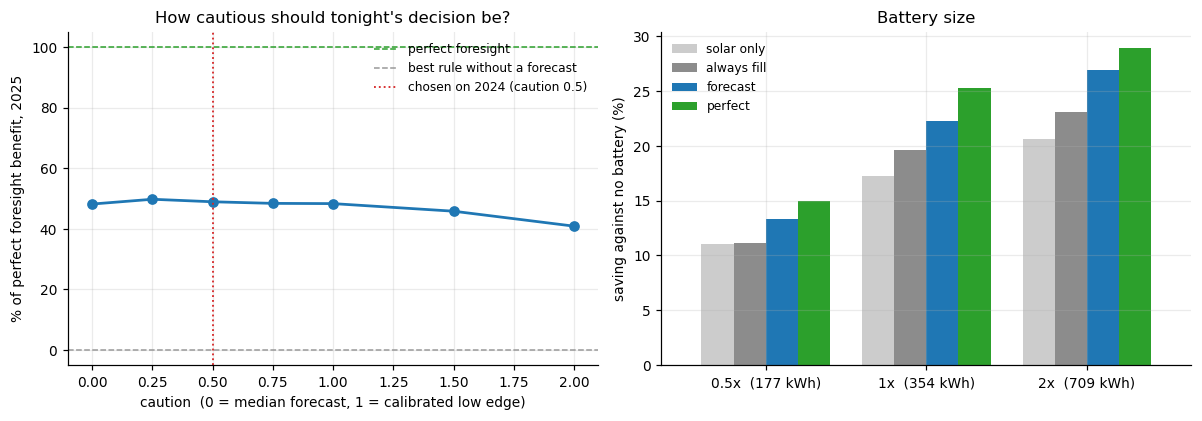

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
ax[0].plot(sweep.index, sweep["captured_2025_%"], "o-", color="#1f77b4", lw=1.8)
ax[0].axhline(100, color="#2ca02c", ls="--", lw=1, label="perfect foresight")
ax[0].axhline(0,   color="#999999", ls="--", lw=1, label="best rule without a forecast")
ax[0].axvline(best_c, color="#d62728", ls=":", lw=1.2, label=f"chosen on 2024 (caution {best_c})")
ax[0].set_xlabel("caution  (0 = median forecast, 1 = calibrated low edge)")
ax[0].set_ylabel("% of perfect foresight benefit, 2025")
ax[0].set_title("How cautious should tonight's decision be?")
ax[0].legend(frameon=False, fontsize=8)

size_tab.plot.bar(ax=ax[1], rot=0, width=.8, color=["#cccccc", "#8c8c8c", "#1f77b4", "#2ca02c"])
ax[1].set_ylabel("saving against no battery (%)")
ax[1].set_title("Battery size"); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"fig13_dispatch_sensitivity.png"); plt.show()

## Step 10 · One week up close

The totals in steps 8 and 9 cover 17 months. Here we zoom into one week of the 2025 test year, centred on its cloudiest fully metered day, so that sunny and cloudy days sit side by side. We compare always filling overnight, the forecast plan (at the caution chosen on 2024) and perfect foresight: what the planner expected, how full the battery was, and how much grid energy each strategy bought each night. Peak hours (16:00 to 21:59) are shaded.

This week the forecast plan cost slightly more than always filling ($1,865 against $1,859). It is shown on purpose: on cloudy days every strategy must fill the battery, so the value of a forecast lies in the sunny days where the right decision is to buy less. Two errors are visible. On Sunday 25 May the demand forecast expected a weekday load and bought grid energy that the sun would have supplied. On Monday 26 and Friday 30 May the solar forecast missed a cloudy day and a very sunny day. Over the full test period the forecast still wins (step 9), and the weekend error is the main improvement planned for Assessment 4.

In [14]:
#10 ·  One week up close: what the nightly decision actually does
pv_best  = pv50 - best_c * (pv50 - pvlo)                       # solar plan at the caution chosen on 2024
week_run = {"always fill overnight": runs["always fill overnight"],
            f"forecast (caution {best_c})": simulate(sim, "planned", pv_best, demf),
            "perfect foresight": runs["perfect foresight"]}

# pick the week: centred on the cloudiest day of 2025 (the test year), where planning matters most
daily_pv = sim.pv.loc["2025-01-04":"2025-08-18"].resample("D").sum()
complete = mask.resample("D").sum().reindex(daily_pv.index) == 24      # only days fully metered
dull     = daily_pv[complete].idxmin()
w0, w1   = dull - pd.Timedelta(days=3), dull + pd.Timedelta(days=4) - pd.Timedelta(hours=1)
wk       = sim.loc[w0:w1]

# grid energy bought overnight (22:00 to 06:59), labelled with the morning it was bought for
def night_grid(r):
    g = r.chg.where((r.index.hour >= 22) | (r.index.hour <= 6), 0)
    return g.groupby((r.index - pd.Timedelta(hours=7)).normalize() + pd.Timedelta(days=1)).sum()

bought = pd.DataFrame({n: night_grid(r) for n, r in week_run.items()}).loc[w0.normalize() + pd.Timedelta(days=1):w1.normalize()]

print(f"example week {w0:%d %b %Y} to {w1:%d %b %Y}, cloudiest day {dull:%a %d %b} "
      f"({daily_pv[dull]:,.0f} kWh against a 2025 median of {daily_pv.median():,.0f} kWh)\n")
print("grid energy bought overnight for each morning (kWh):\n")
print(bought.round(0).to_string())
print("\ncost over the week ($):")
wm = mask & (sim.index >= w0) & (sim.index <= w1)
for n, r in week_run.items():
    print(f"  {n:<28} {cost(r, wm):8,.0f}")

example week 24 May 2025 to 30 May 2025, cloudiest day Tue 27 May (124 kWh against a 2025 median of 1,293 kWh)

grid energy bought overnight for each morning (kWh):

            always fill overnight  forecast (caution 0.5)  perfect foresight
2025-05-25                  246.0                   186.0                0.0
2025-05-26                  233.0                   185.0              233.0
2025-05-27                  358.0                   361.0              358.0
2025-05-28                  361.0                   361.0              361.0
2025-05-29                  361.0                   361.0              361.0
2025-05-30                  361.0                   361.0               89.0

cost over the week ($):
  always fill overnight           1,859
  forecast (caution 0.5)          1,865
  perfect foresight               1,796


**Figure 14.** The example week. Top: forecast against actual for solar and demand. Middle: energy stored in the battery. Bottom: grid energy bought overnight for each morning.

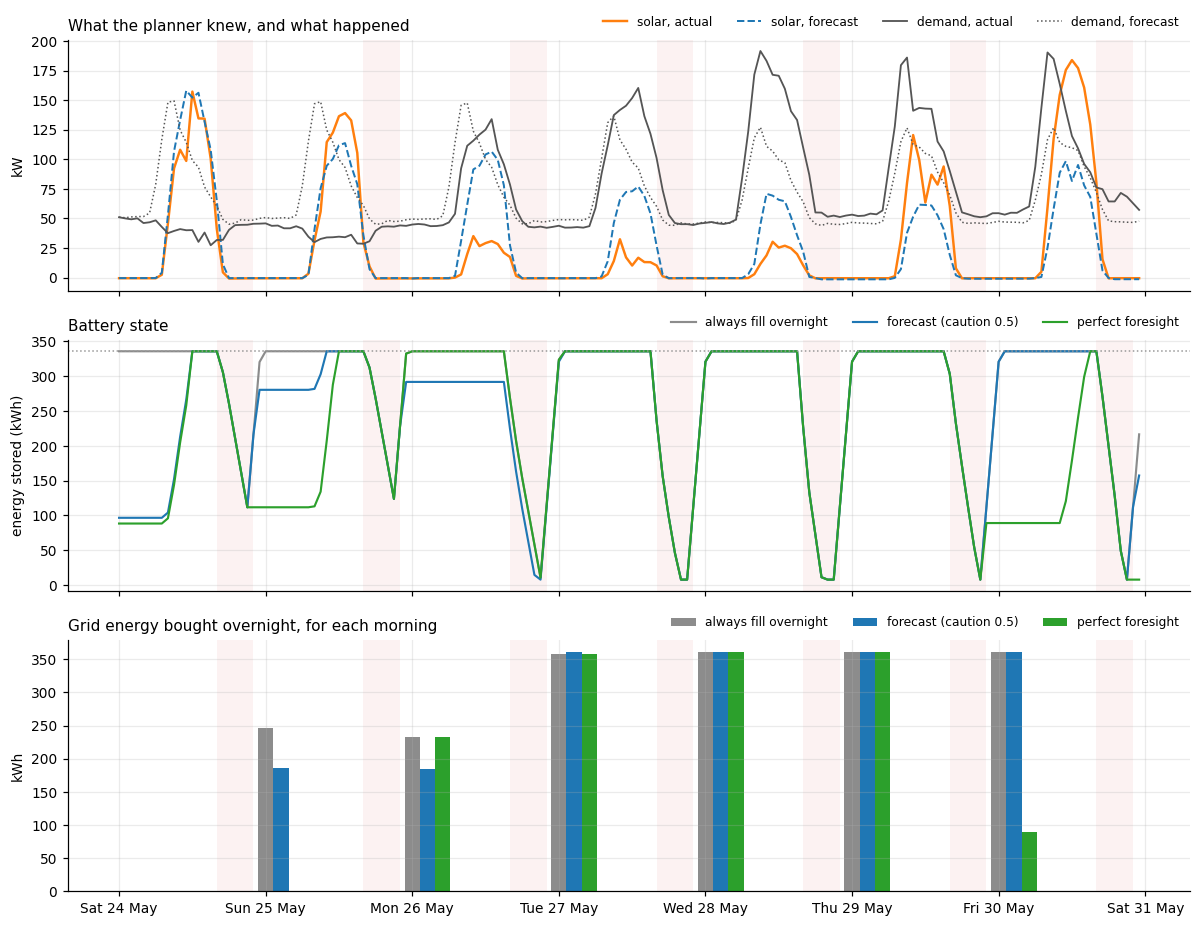

In [15]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)

ax[0].plot(wk.index, wk.pv, color="#ff7f0e", lw=1.6, label="solar, actual")
ax[0].plot(wk.index, pv_best[sim.index.get_indexer(wk.index)], color="#1f77b4", lw=1.3, ls="--",
           label="solar, forecast")
ax[0].plot(wk.index, wk.demand, color="#555555", lw=1.2, label="demand, actual")
ax[0].plot(wk.index, wk.dem_fc, color="#555555", lw=1, ls=":", label="demand, forecast")
ax[0].set_ylabel("kW"); ax[0].set_title("What the planner knew, and what happened", loc="left", fontsize=10)
ax[0].legend(frameon=False, fontsize=8, ncol=4, loc="lower right", bbox_to_anchor=(1, 1))

cols = {"always fill overnight": "#8c8c8c", f"forecast (caution {best_c})": "#1f77b4", "perfect foresight": "#2ca02c"}
for n, r in week_run.items():
    ax[1].plot(r.loc[w0:w1].index, r.stored.loc[w0:w1], color=cols[n], lw=1.4, label=n)
ax[1].axhline(BATT["soc_max"] * BATT["capacity_kwh"], color="#999999", ls=":", lw=1)
ax[1].set_ylabel("energy stored (kWh)"); ax[1].set_title("Battery state", loc="left", fontsize=10)
ax[1].legend(frameon=False, fontsize=8, ncol=3, loc="lower right", bbox_to_anchor=(1, 1))

x, wd = bought.index + pd.Timedelta(hours=2.5), pd.Timedelta(hours=2.5)   # bars sit on the night itself
for i, n in enumerate(bought.columns):
    ax[2].bar(x + (i - 1) * wd, bought[n], width=wd, color=cols[n], label=n)
ax[2].set_ylabel("kWh"); ax[2].set_title("Grid energy bought overnight, for each morning", loc="left", fontsize=10)
ax[2].legend(frameon=False, fontsize=8, ncol=3, loc="lower right", bbox_to_anchor=(1, 1))

for a in ax:
    for d in pd.date_range(w0.normalize(), w1, freq="D"):
        a.axvspan(d + pd.Timedelta(hours=16), d + pd.Timedelta(hours=22), color="#d62728", alpha=.06, lw=0)
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
fig.tight_layout(); fig.savefig(FIG/"fig14_example_week.png"); plt.show()

## Step 11 · Save the results and a KPI summary

The calibrated forecasts and the hourly simulation are saved to `Data/processed` for Assessment 4. The key indicators, following the decision support KPIs of Week 8, are written with every result table to `Outputs/dispatch_results.md`.

In [16]:
# 11 · Save the results and a one page KPI summary 
# 1) calibrated forecasts, reused in Assessment 4
keep = ["issue_time", "target_time", "horizon", "fold", "actual", "p50", "lo_c", "hi_c", "is_daylight"]
fc[keep].to_parquet(PROC/"forecasts_calibrated.parquet", index=False)

# 2) hour by hour simulation: the inputs and each strategy's grid import, export and stored energy
final = {"no_battery": runs["no battery"], "always_fill": runs["always fill overnight"],
         "forecast": week_run[f"forecast (caution {best_c})"], "perfect": runs["perfect foresight"]}
hourly_out = sim.copy()
for n, r in final.items():
    hourly_out[[f"{n}_{c}" for c in ["imp", "exp", "stored"]]] = r[["imp", "exp", "stored"]].to_numpy()
hourly_out.to_parquet(PROC/"dispatch_hourly.parquet")

# 3) KPI table: coverage of the calibrated interval, and what the battery decision is worth
dl  = fc[fc.is_daylight.astype(bool) & fc.lo_c.notna()]
cov = dl.actual.between(dl.lo_c, dl.hi_c).groupby(dl.horizon).mean()

usable = (BATT["soc_max"] - BATT["soc_min"]) * BATT["capacity_kwh"]
fc_cost = cost(final["forecast"], mask)
kpi = pd.DataFrame({
    "value": [f"{100*cov.get(1, np.nan):.1f}%", f"{100*cov.get(24, np.nan):.1f}%",
              f"${base_c:,.0f}", f"${fc_cost:,.0f}", f"{100*(1 - fc_cost/base_c):.1f}%",
              f"${best_blind - fc_cost:,.0f}",
              f"{100*(best_blind - fc_cost)/(best_blind - perfect):.0f}%",
              f"{final['forecast'].dis[mask].sum()/usable:.0f}",
              f"{final['forecast'].exp[mask].sum()/1e3:.1f} MWh"],
    "meaning": ["share of daylight hours inside the 80% interval, 1 h ahead (target 80%)",
                "same, 24 h ahead (target 80%)",
                "energy cost with no battery, illustrative tariff",
                f"energy cost, battery planned with the forecast (caution {best_c})",
                "saving against no battery",
                "saving against the better rule without a forecast",
                "share of the perfect foresight benefit captured",
                "equivalent full battery cycles over the period",
                "solar exported instead of stored or used"]},
    index=["coverage 1 h", "coverage 24 h", "cost, no battery", "cost, forecast plan", "saving",
           "value of the forecast", "benefit captured", "full cycles", "export"])
kpi.index.name = "KPI"
print(kpi.to_string())

# 4) write everything to one markdown file in Outputs/
def md(df, fmt="{:,.1f}"):
    df = df.reset_index()
    cells = [[fmt.format(v) if isinstance(v, (float, np.floating)) else str(v) for v in row]
             for row in df.itertuples(index=False)]
    lines = ["| " + " | ".join(map(str, df.columns)) + " |", "|" + "---|" * len(df.columns)]
    return "\n".join(lines + ["| " + " | ".join(r) + " |" for r in cells])

scored_days = mask.sum() / 24
report = f"""# Battery dispatch results (notebook 06)

Scored on {mask.sum():,} hours ({scored_days:.0f} days), {sim.index.min():%d %b %Y} to {sim.index.max():%d %b %Y}.
Illustrative time of use tariff: off peak ${TARIFF['offpeak']}, shoulder ${TARIFF['shoulder']}, peak ${TARIFF['peak']} per kWh, feed in ${FEED_IN}.
Battery modelled from site telemetry: {BATT['capacity_kwh']:.0f} kWh, {BATT['p_charge_kw']:.0f} kW, one way efficiency {BATT['eta_oneway']:.3f}.

## Key indicators
{md(kpi)}

## Strategies compared
{md(table.rename_axis("strategy"))}

## Which forecast limits the result
{md(pd.DataFrame({"cost_$": dc, "share_of_perfect_%": 100*(best_blind - dc)/(best_blind - perfect)}).rename_axis("setup"), "{:,.0f}")}

## Caution level (chosen on 2024, judged on 2025)
{md(sweep, "{:,.0f}")}

## Battery size (saving against no battery, %)
{md(size_tab.rename_axis("battery size"))}

Figures: fig11_interval_calibration.png, fig12_site_average_day.png, fig13_dispatch_sensitivity.png, fig14_example_week.png
"""
(OUT/"dispatch_results.md").write_text(report)
table.to_csv(OUT/"dispatch_strategies.csv")

for p in [PROC/"forecasts_calibrated.parquet", PROC/"dispatch_hourly.parquet",
          OUT/"dispatch_results.md", OUT/"dispatch_strategies.csv"]:
    print(f"saved  {p.name:<32} {p.stat().st_size/1e3:8,.0f} kB")

                           value                                                                  meaning
KPI                                                                                                      
coverage 1 h               80.1%  share of daylight hours inside the 80% interval, 1 h ahead (target 80%)
coverage 24 h              80.0%                                            same, 24 h ahead (target 80%)
cost, no battery        $128,709                         energy cost with no battery, illustrative tariff
cost, forecast plan      $99,999             energy cost, battery planned with the forecast (caution 0.5)
saving                     22.3%                                                saving against no battery
value of the forecast     $3,419                        saving against the better rule without a forecast
benefit captured             47%                          share of the perfect foresight benefit captured
full cycles                  361              

## Summary and next steps

**A · A trustworthy forecast.** Rolling conformal calibration (30 day window, only information available at the time) brings daylight coverage of the 80% interval to 80.1% at 1 h and 80.0% at 24 h, between 79.3% and 81.0% in every fold, and halves the month to month spread.

**B · Understanding the site.** The site telemetry balances as demand = solar + grid + battery. A configuration change at the end of February 2024 halved the ratio of site solar to Master Meter 1 (2.21 to about 1.13), a clear case of data drift, so the analysis starts on 1 March 2024 with a scaling factor of 1.135. The battery, modelled from its own telemetry, holds 354 kWh with an 82.8% round trip efficiency.

**C · Deciding and evaluating.** A nightly decision at 22:00, informed by the 24 h forecast, cuts the illustrative energy cost by 22.3% and saves $3,419 more than the best rule without a forecast, capturing 47% of the perfect foresight benefit. The caution level was chosen on 2024 and confirmed on 2025, and the forecast adds value at every battery size tested.

**Next steps for Assessment 4.**
1. Improve the demand forecast (weekday and weekend patterns, temperature): with perfect demand the same solar forecast would capture 85% of the benefit.
2. Replace the rule with an optimiser (linear programming) that plans charge and discharge together and stores more of the exported solar.
3. Monitor coverage and drift over time and retrain on a rolling schedule, following the MLOps practice of Week 9.